In [1]:
import numpy as np
import pandas as pd
import time
import sys


if '../src' in sys.path:
    sys.path.remove('../src') 

sys.path.append('../src')

from blackjack_core import hand_berechnen, deck_erstellen, karte_austeilen
from blackjack_t2 import berechne_kommende_karte, gewinnt_spieler, denk_logik, spielerrunde

# Testen der "21er Schätzer" 

In [2]:
a_21er_test_1 = []
a_21er_test_2 = []
a1 = [10,9,8,7,6,5,4,3,2,1] #
wert1 = []
ueberschiesst1 = []
alle_wert1 = []
gewinnt_spieler1 = []


a2 = [9, 8, 7, 6, 5, 4, 3, 2, 1]
wert2 = []
ueberschiesst2 = []
alle_wert1 = []

wert_nach_schaetzung = 0
gewinnt_spieler2 = []

In [ ]:
deck = deck_erstellen(6)
bisherige_karten = []
ueberschiesst = 0
uebrige_karten = len(deck)


startegien = ['erster Test'] # 'zweiter Test'

for s in startegien:
    for i in a1:
        spieler_total_buget = 0
        dealer_total_buget = 0
        gewinnt_spieler1 = []
        ueberschiesst = 0
        runden = 0
        # teil_alle_wert1 = []

        deck = deck_erstellen(6)
        spieler_buget = 1000
        dealer_buget = 1000
        bisherige_karten = []
        uebrige_karten = 0
        uebrige_karten = len(deck)
        iterations = 1_000_000
        for j in range(iterations):
            if uebrige_karten <= 5:
                runden += 1
                deck = deck_erstellen(6)
                spieler_buget = 1000
                dealer_buget = 1000
                bisherige_karten = []
                uebrige_karten = 0
                uebrige_karten = len(deck)
            
            spieler_buget, dealer_buget, spieler_karten_total, dealer_karten_total, deck, bisherige_karten, spielerstrategie, gewinnt_spieler = spielerrunde(1000, 1000, deck, bisherige_karten, s, a=i)
            gewinnt_spieler1.append(gewinnt_spieler)
            t_hand = hand_berechnen(spieler_karten_total)
            wert_nach_schaetzung += t_hand

            # teil_alle_wert1.append(t_hand)

            # print(teil_alle_wert1)

            if hand_berechnen(spieler_karten_total) > 21:
                ueberschiesst += 1

            
            uebrige_karten = len(deck)
        
        spieler_total_buget += spieler_buget
        dealer_total_buget += dealer_buget

        # alle_wert1.append(teil_alle_wert1)
        wert_nach_schaetzung /= iterations
        ueberschiesst = ueberschiesst / iterations
        wert1.append(wert_nach_schaetzung)
        ueberschiesst1.append(ueberschiesst)
        print('wert ',wert_nach_schaetzung)
        print('ueberschiesst ', ueberschiesst)

        wert_nach_schaetzung = 0
        ueberschiesst = 0

        total_gewinnt = 0
        total_verlust = 0
        for i in gewinnt_spieler1:
            if i == True:
                total_gewinnt += 1
            else:
                total_verlust += 1

        print((total_gewinnt+total_verlust) / total_gewinnt)

        print('Spieler total buget ', spieler_total_buget)
        print('Dealer total buget ', dealer_total_buget)
        print('runden ', runden)

    print()
    print()
    print()

    #Parameter in berechene_in_karte fehlt

wert  18.123819
ueberschiesst  0.165485
1.5237863042086979
Spieler total buget  920.0
Dealer total buget  1080.0
runden  16214
wert  18.366377
ueberschiesst  0.175222
1.563073941212789
Spieler total buget  920.0
Dealer total buget  1080.0
runden  16273
wert  18.65008
ueberschiesst  0.190931
1.622423186374241
Spieler total buget  1010
Dealer total buget  990
runden  16325
wert  18.931148
ueberschiesst  0.209494
1.694831948938103
Spieler total buget  860.0
Dealer total buget  1140.0
runden  16361
wert  19.20982
ueberschiesst  0.230797
1.786291640691009
Spieler total buget  990
Dealer total buget  1010
runden  16376
wert  19.518714
ueberschiesst  0.2584
1.915679453188457
Spieler total buget  990
Dealer total buget  1010
runden  16380
wert  19.463361
ueberschiesst  0.256157
1.8922908072512583
Spieler total buget  1050.0
Dealer total buget  950.0
runden  16353
wert  19.481082
ueberschiesst  0.262917
1.8878503614289517
Spieler total buget  920.0
Dealer total buget  1080.0
runden  16322


##### Test 1: +50 (best)
##### Test 2: +50

In [4]:


print(spieler_total_buget)
print(dealer_total_buget)



0
0


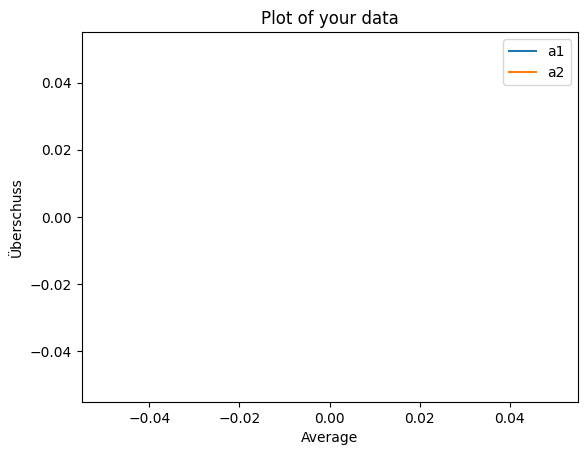

In [5]:
import matplotlib.pyplot as plt

plt.plot(wert1, ueberschiesst1, label='a1')
plt.legend()
plt.title('Plot of your data')


plt.plot(wert2, ueberschiesst2, label='a2')
plt.xlabel('Average')
plt.ylabel('Überschuss')
plt.legend()
plt.title('Plot of your data')
plt.show()
